# Nova Pay Fraud Detection - Step 3 & 4
## Feature Engineering, Standardization & Exploratory Data Analysis

**Workflow Steps:**
- **Step 3**: Standardize and Engineer Features (velocity metrics, device fingerprints, mismatch indicators, temporal patterns)
- **Step 4**: Exploratory Data Analysis (patterns by channel, geography, time; anomaly identification)

**Input Data**: `nova_pay_clean.csv`
**Output Data**: `nova_pay_engineered_scaled.csv`

---
**Identifier handling (continued from data cleaning):** In data cleaning we learned to keep identifier columns (`transaction_id`, `customer_id`, `device_id`, `ip_address`) aside so they never leak into the model. EDA still *uses* `customer_id` / `device_id` to engineer behaviour features by grouping. Right before encoding (Step 3.10b), we do the **final separation**: we drop the raw identifiers entirely, keeping only the behaviour features derived from them. This is what prevents the "25,000 columns" one-hot-encoding explosion.

## STEP 1: IMPORT REQUIRED LIBRARIES

In [29]:
# Install required packages
!pip install pandas numpy scikit-learn matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy import stats
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ All libraries imported successfully')

✓ All libraries imported successfully



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## STEP 2: LOAD AND INSPECT CLEANED DATA

In [30]:
# Load cleaned data
df = pd.read_csv('../data/nova_pay_cleaned.csv')

print('=' * 80)
print('CLEANED DATASET LOADED')
print('=' * 80)
print(f'Shape: {df.shape}')
print(f'\nData Types:\n{df.dtypes}')
print(f'\nMissing Values:\n{df.isnull().sum()}')
print(f'\nFirst few rows:')
print(df.head())

CLEANED DATASET LOADED
Shape: (11200, 33)

Data Types:
transaction_id                     str
customer_id                        str
timestamp                          str
home_country                       str
source_currency                    str
dest_currency                      str
channel                            str
amount_src                     float64
amount_usd                     float64
fee                            float64
exchange_rate_src_to_dest      float64
device_id                          str
new_device                        bool
ip_address                         str
ip_country                         str
location_mismatch                 bool
ip_risk_score                  float64
kyc_tier                           str
account_age_days               float64
device_trust_score             float64
chargeback_history_count       float64
risk_score_internal            float64
txn_velocity_1h                float64
txn_velocity_24h               float64
corridor_

In [31]:
# Summary statistics
print('\nSummary Statistics:')
print(df.describe())

# Class distribution
print(f'\nClass Distribution:')
print(df['is_fraud'].value_counts())
print(f'\nFraud Rate: {df["is_fraud"].mean():.2%}')


Summary Statistics:
         amount_src    amount_usd           fee  exchange_rate_src_to_dest  \
count  11200.000000  11200.000000  11200.000000               11200.000000   
mean     441.139541    451.146856      7.648923                 167.453693   
std     1360.470203   1393.448332     20.580647                 381.930143   
min        7.230000      7.230000      0.500000                   0.592000   
25%       92.515000     92.740000      2.400000                   1.000000   
50%      161.275000    163.925000      3.500000                   7.142857   
75%      297.790000    303.092500      5.490000                  73.529412   
max    11942.890000  12498.570000    179.740000                1388.888889   

       ip_risk_score  account_age_days  device_trust_score  \
count   11200.000000      11200.000000        11200.000000   
mean        0.382210        392.848571            0.668689   
std         0.249286        342.123998            0.254300   
min         0.004000        

In [32]:
# Convert timestamp to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
print(f"Non-null timestamps: {df['timestamp'].notnull().sum()}")
print(f'Timestamp range: {df["timestamp"].min()} to {df["timestamp"].max()}')
duration = df["timestamp"].max() - df["timestamp"].min()
print(f'Total duration: {duration}')

Non-null timestamps: 11200
Timestamp range: 2022-10-03 18:40:59.468549+00:00 to 2025-12-16 00:13:41.468549+00:00
Total duration: 1169 days 05:32:42


# STEP 3: STANDARDIZE AND ENGINEER FEATURES

### 3.1: Extract Temporal Features

In [33]:
# Extract temporal features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_month'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['quarter'] = df['timestamp'].dt.quarter
df['is_weekday'] = df['day_of_week'] < 5  # Monday-Friday
df['is_weekend'] = df['day_of_week'] >= 5  # Saturday-Sunday
df['is_business_hours'] = (df['hour'] >= 9) & (df['hour'] < 17)  # 9 AM - 5 PM
df['is_night'] = (df['hour'] >= 22) | (df['hour'] < 6)  # 10 PM - 6 AM

print('✓ Temporal features created:')
print(df[['hour', 'day_of_week', 'month', 'is_weekday', 'is_business_hours']].head())

✓ Temporal features created:
   hour  day_of_week  month  is_weekday  is_business_hours
0    18            0     10        True              False
1    20            0     10        True              False
2    23            0     10        True              False
3     1            1     10        True              False
4     9            1     10        True               True


### 3.2: Engineer Velocity Metrics

In [34]:
# Velocity metrics - customer level
customer_txn_count = df.groupby('customer_id').size().to_dict()
df['customer_total_transactions'] = df['customer_id'].map(customer_txn_count)

# High velocity indicator - customers with >median transactions
median_txn = df['customer_total_transactions'].median()
df['high_velocity_customer'] = (df['customer_total_transactions'] > median_txn).astype(int)

# Velocity spikes (if velocity columns exist, identify spikes)
if 'txn_velocity_1h' in df.columns:
    velocity_1h_75th = df['txn_velocity_1h'].quantile(0.75)
    df['velocity_spike_1h'] = (df['txn_velocity_1h'] > velocity_1h_75th).astype(int)
else:
    df['velocity_spike_1h'] = 0

if 'txn_velocity_24h' in df.columns:
    velocity_24h_75th = df['txn_velocity_24h'].quantile(0.75)
    df['velocity_spike_24h'] = (df['txn_velocity_24h'] > velocity_24h_75th).astype(int)
else:
    df['velocity_spike_24h'] = 0

print('✓ Velocity metrics created:')
print(df[['customer_total_transactions', 'high_velocity_customer', 'velocity_spike_1h']].describe())

✓ Velocity metrics created:
       customer_total_transactions  high_velocity_customer  velocity_spike_1h
count                 11200.000000            11200.000000       11200.000000
mean                    818.178929                0.462054           0.109821
std                     534.241015                0.498580           0.312681
min                       1.000000                0.000000           0.000000
25%                     343.000000                0.000000           0.000000
50%                     893.000000                0.000000           0.000000
75%                    1325.000000                1.000000           0.000000
max                    1483.000000                1.000000           1.000000


### 3.3: Engineer Device Fingerprints

In [35]:
# Device fingerprint features
# Count unique devices per customer
customer_devices = df.groupby('customer_id')['device_id'].nunique().to_dict() if 'device_id' in df.columns else {}
df['customer_device_count'] = df['customer_id'].map(customer_devices) if customer_devices else 1

# Multi-device indicator
df['multi_device_user'] = (df['customer_device_count'] > 1).astype(int)

# Count unique IPs per customer
customer_ips = df.groupby('customer_id')['ip_address'].nunique().to_dict() if 'ip_address' in df.columns else {}
df['customer_ip_count'] = df['customer_id'].map(customer_ips) if customer_ips else 1

# Device fingerprint risk score
device_fraud_rate = df.groupby('device_id' if 'device_id' in df.columns else 'customer_id')['is_fraud'].mean().to_dict() if 'device_id' in df.columns else {}
df['device_fingerprint_risk'] = df['device_id'].map(device_fraud_rate) if 'device_id' in df.columns and device_fraud_rate else 0

print('✓ Device fingerprint features created:')
print(df[['customer_device_count', 'multi_device_user', 'customer_ip_count']].describe())

✓ Device fingerprint features created:
       customer_device_count  multi_device_user  customer_ip_count
count           11200.000000       11200.000000       11200.000000
mean               67.976071           0.875714         793.588125
std                45.755551           0.329922         517.182500
min                 1.000000           0.000000           1.000000
25%                17.000000           1.000000         334.000000
50%                84.000000           1.000000         864.000000
75%               100.000000           1.000000        1284.000000
max               143.000000           1.000000        1443.000000


### 3.4: Engineer Mismatch Indicators

In [36]:
# Mismatch indicators
# Country-location mismatch
df['country_location_mismatch'] = 0
if 'home_country' in df.columns and 'ip_country' in df.columns:
    df['country_location_mismatch'] = (df['home_country'] != df['ip_country']).astype(int)

# Geo-anomaly: transaction from unusual location for this customer
customer_countries = df.groupby('customer_id')['home_country'].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]).to_dict()
df['expected_country'] = df['customer_id'].map(customer_countries)
df['geo_anomaly'] = 0
if 'ip_country' in df.columns:
    df['geo_anomaly'] = (df['ip_country'] != df['expected_country']).astype(int)

# Currency mismatch
df['currency_mismatch'] = 0
if 'source_currency' in df.columns and 'home_country' in df.columns:
    # Simple heuristic: if source currency doesn't match country code
    df['currency_mismatch'] = 0  # Can be enhanced based on currency-country mapping

# Total mismatch indicators
df['total_mismatch_indicators'] = (df['country_location_mismatch'] + 
                                   df['geo_anomaly'] + 
                                   df['currency_mismatch'])

df['high_mismatch'] = (df['total_mismatch_indicators'] >= 2).astype(int)

print('✓ Mismatch indicators created:')
print(df[['country_location_mismatch', 'geo_anomaly', 'total_mismatch_indicators', 'high_mismatch']].describe())

✓ Mismatch indicators created:
       country_location_mismatch   geo_anomaly  total_mismatch_indicators  \
count               11200.000000  11200.000000               11200.000000   
mean                    0.195179      0.193482                   0.388661   
std                     0.396356      0.395045                   0.790331   
min                     0.000000      0.000000                   0.000000   
25%                     0.000000      0.000000                   0.000000   
50%                     0.000000      0.000000                   0.000000   
75%                     0.000000      0.000000                   0.000000   
max                     1.000000      1.000000                   2.000000   

       high_mismatch  
count   11200.000000  
mean        0.193482  
std         0.395045  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         1.000000  


### 3.5: Engineer Transaction Amount Features

In [37]:
# Transaction amount features
if 'amount_usd' in df.columns:
    # Log transformation of amount
    df['log_amount_usd'] = np.log1p(df['amount_usd'])  # log1p handles zeros
    
    
# Amount quantile for customer
def safe_qcut(x):
    try:
        return pd.qcut(x, q=4, labels=[1, 2, 3, 4], duplicates='drop')
    except ValueError:
        return pd.Series([np.nan] * len(x), index=x.index)

df['amount_quantile'] = (
    df.groupby('customer_id')['amount_usd']
      .apply(safe_qcut)
      .values
)

    
# Fee ratio
if 'fee' in df.columns and 'amount_usd' in df.columns:
    df['fee_ratio'] = df['fee'] / (df['amount_usd'] + 1)  # Add 1 to avoid division by zero
    df['high_fee'] = (df['fee_ratio'] > df['fee_ratio'].quantile(0.90)).astype(int)
else:
    df['fee_ratio'] = 0
    df['high_fee'] = 0

print('✓ Transaction amount features created:')
print(df[['log_amount_usd', 'fee_ratio', 'high_fee']].describe())

✓ Transaction amount features created:
       log_amount_usd     fee_ratio      high_fee
count    11200.000000  11200.000000  11200.000000
mean         5.209288      0.023610      0.100000
std          1.045507      0.018121      0.300013
min          2.107786      0.000314      0.000000
25%          4.540525      0.016985      0.000000
50%          5.105491      0.020559      0.000000
75%          5.717332      0.026271      0.000000
max          9.433450      1.413285      1.000000


### 3.6: Engineer Risk Profiles

In [38]:
# KYC Risk Score
kyc_risk_mapping = {'basic': 2, 'standard': 1, 'enhanced': 0}  # Adjust based on actual values
if 'kyc_tier' in df.columns:
    df['kyc_risk_score'] = df['kyc_tier'].map(kyc_risk_mapping).fillna(1)
else:
    df['kyc_risk_score'] = 1

# New account indicator - account age less than 30 days
if 'account_age_days' in df.columns:
    df['is_new_account'] = (df['account_age_days'] < 30).astype(int)
else:
    df['is_new_account'] = 0

# Device trust score anomaly
if 'device_trust_score' in df.columns:
    df['low_device_trust'] = (df['device_trust_score'] < df['device_trust_score'].quantile(0.25)).astype(int)
else:
    df['low_device_trust'] = 0

# Combined risk score
df['combined_risk_score'] = (df['kyc_risk_score'] + 
                             df['is_new_account'] + 
                             df['multi_device_user'] + 
                             df['high_velocity_customer'] + 
                             df['high_mismatch'] +
                             df['low_device_trust'])

print('✓ Risk profile features created:')
print(df[['kyc_risk_score', 'is_new_account', 'combined_risk_score']].describe())

✓ Risk profile features created:
       kyc_risk_score  is_new_account  combined_risk_score
count    11200.000000    11200.000000         11200.000000
mean         0.835804        0.170179             2.784196
std          0.370470        0.375806             1.091305
min          0.000000        0.000000             0.000000
25%          1.000000        0.000000             2.000000
50%          1.000000        0.000000             3.000000
75%          1.000000        0.000000             4.000000
max          1.000000        1.000000             6.000000


### 3.7: Engineer Channel and Corridor Features

In [39]:
# Channel risk - fraud rate by channel
if 'channel' in df.columns:
    channel_fraud_rate = df.groupby('channel')['is_fraud'].mean().to_dict()
    df['channel_risk'] = df['channel'].map(channel_fraud_rate)
else:
    df['channel_risk'] = 0

# Corridor fraud rate (source country to dest country)
if 'source_currency' in df.columns and 'dest_currency' in df.columns:
    df['corridor'] = df['source_currency'] + '_' + df['dest_currency']
    corridor_fraud_rate = df.groupby('corridor')['is_fraud'].mean().to_dict()
    df['corridor_fraud_rate'] = df['corridor'].map(corridor_fraud_rate)
else:
    df['corridor_fraud_rate'] = 0

print('✓ Channel and corridor features created:')
print(df[['channel_risk', 'corridor_fraud_rate']].describe())

✓ Channel and corridor features created:
       channel_risk  corridor_fraud_rate
count  11200.000000         11200.000000
mean       0.088839             0.088839
std        0.053675             0.101408
min        0.027027             0.017241
25%        0.046755             0.029508
50%        0.046755             0.052239
75%        0.163038             0.119276
max        0.163038             0.604520


### 3.8: Prepare Data for Scaling

In [40]:
# Identify feature types
print('Features created so far:')
print(f'Shape: {df.shape}')
print(f'\nNew columns: {df.shape[1] - 30}')  # Approximate original columns

print('\nSample of engineered features:')
print(df[['hour', 'customer_total_transactions', 'multi_device_user', 
          'country_location_mismatch', 'log_amount_usd', 'combined_risk_score']].head(10))

Features created so far:
Shape: (11200, 61)

New columns: 31

Sample of engineered features:
   hour  customer_total_transactions  multi_device_user  \
0    18                         1483                  1   
1    20                          349                  1   
2    23                         1045                  1   
3     1                          793                  1   
4     9                          662                  1   
5    12                           81                  1   
6    12                          349                  1   
7    16                           91                  1   
8    21                         1045                  1   
9    21                          384                  1   

   country_location_mismatch  log_amount_usd  combined_risk_score  
0                          0        5.631893                  3.0  
1                          0        5.045294                  3.0  
2                          0        5.083452         

### 3.9: Standardize Numerical Features

In [41]:
# Identify numerical columns for scaling
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target and ID columns from scaling
exclude_cols = ['is_fraud', 'customer_id', 'transaction_id']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print(f'Numerical columns to scale ({len(numerical_cols)}): {numerical_cols[:10]}...')

# Initialize and fit scaler on entire dataset
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print('\n✓ StandardScaler applied')
print(f'\nScaled features statistics (mean ≈ 0, std ≈ 1):')
print(df_scaled[numerical_cols].describe().loc[['mean', 'std']])

Numerical columns to scale (40): ['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h']...

✓ StandardScaler applied

Scaled features statistics (mean ≈ 0, std ≈ 1):
        amount_src    amount_usd           fee  exchange_rate_src_to_dest  \
mean -3.806479e-17  2.283887e-17 -3.045183e-17               2.537653e-17   
std   1.000045e+00  1.000045e+00  1.000045e+00               1.000045e+00   

      ip_risk_score  account_age_days  device_trust_score  \
mean   8.120488e-17      7.105427e-17        7.105427e-17   
std    1.000045e+00      1.000045e+00        1.000045e+00   

      chargeback_history_count  risk_score_internal  txn_velocity_1h  ...  \
mean             -1.015061e-17         1.624098e-16    -4.060244e-17  ...   
std               1.000045e+00         1.000045e+00     1.000045e+00  ...   

      log_amount_usd  amount_quantile     fee_r

### 📚 TEACHING NOTE — What is one-hot encoding, and why do we do it?

**The problem.** Machine-learning models do arithmetic — they can only consume *numbers*. But columns like `channel` hold text: `"mobile"`, `"web"`, `"atm"`. We must convert text categories into numbers without lying to the model.

**The naïve (wrong) way: label encoding.** We could map `mobile→0, web→1, atm→2`. But this invents a false order and false distances: it tells the model `atm (2)` is "twice" `web (1)` and that `web` sits "between" `mobile` and `atm`. For an unordered category that is meaningless and actively misleads the model.

**The right way: one-hot encoding.** We create one new 0/1 column per category. Each row gets a `1` in the column for its category and `0` everywhere else:

| channel | → | channel_mobile | channel_web | channel_atm |
|---|---|---|---|---|
| mobile | | 1 | 0 | 0 |
| web | | 0 | 1 | 0 |
| atm | | 0 | 0 | 1 |

No false ordering, no false distances — each category is simply present or absent.

**`drop_first=True`.** If we already know `channel_web=0` and `channel_atm=0`, then the row must be `mobile` — so the first category is redundant and we drop it. This avoids the "dummy variable trap" (perfectly correlated columns that destabilise linear models) and saves a column.

**Why one-hot is only safe on LOW-cardinality columns.** One-hot adds one column per unique value. For `channel` (≈3 values) that is fine. For `customer_id` (thousands of values) it is a catastrophe — thousands of columns, each almost always zero. **This is exactly why we separated the identifiers in Step 3.10b.** One-hot encoding is for *descriptive categories with few values*, never for *identifiers*.

### 3.10: Encode Categorical Features

### 3.10b: SEPARATE IDENTIFIERS BEFORE ENCODING (the fix for the 25,000-column problem)

By now we have used `customer_id` and `device_id` to build behaviour features such as `customer_total_transactions` and `customer_device_count`. The raw identifiers have done their job — **they must now be removed before one-hot encoding**, or each unique ID will become its own column.

We pull the identifiers into `identifiers_df` (keeping them for later reference/joining) and drop them from the modelling frame.

In [42]:
print('\n🔍 FINAL IDENTIFIER SEPARATION (before encoding)\n')

# The identifier columns we must never one-hot encode
identifier_cols = [c for c in ['transaction_id', 'customer_id', 'device_id', 'ip_address']
                   if c in df.columns]

# Show the damage they WOULD cause if encoded
print('If these were one-hot encoded, they would create this many columns:')
total_id_dummies = 0
for c in identifier_cols:
    nu = df[c].nunique()
    total_id_dummies += nu
    print(f'  {c:18}: {nu:,} dummy columns')
print(f'  → TOTAL unnecessary columns avoided: ~{total_id_dummies:,}')

# Keep identifiers aside (aligned by index), then drop from the modelling frame
df = df.reset_index(drop=True)
identifiers_df = df[identifier_cols].copy()
df = df.drop(columns=identifier_cols)

print(f'\n✓ Identifiers moved to identifiers_df {identifiers_df.shape}')
print(f'✓ Modelling frame df now has {df.shape[1]} columns (identifiers removed)')
print(f'✓ Behaviour features derived from those IDs are retained, e.g.:')
for f in ['customer_total_transactions', 'customer_device_count', 'customer_ip_count']:
    if f in df.columns:
        print(f'     • {f}')


🔍 FINAL IDENTIFIER SEPARATION (before encoding)

If these were one-hot encoded, they would create this many columns:
  transaction_id    : 11,200 dummy columns
  customer_id       : 1,315 dummy columns
  device_id         : 2,113 dummy columns
  ip_address        : 10,901 dummy columns
  → TOTAL unnecessary columns avoided: ~25,529

✓ Identifiers moved to identifiers_df (11200, 4)
✓ Modelling frame df now has 57 columns (identifiers removed)
✓ Behaviour features derived from those IDs are retained, e.g.:
     • customer_total_transactions
     • customer_device_count
     • customer_ip_count


In [43]:
# Identify categorical columns to encode

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {categorical_cols}')

Categorical columns: ['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier', 'currency_pair', 'expected_country', 'corridor']


In [44]:
# Exclude timestamp and other non-feature columns

# Defensive exclusion: identifiers should already be removed in Step 3.10b,
# but we also list them here so encoding stays safe even if run standalone.
exclude_cat = ['timestamp', 'expected_country', 'corridor',
               'transaction_id', 'customer_id', 'device_id', 'ip_address']
categorical_cols = [col for col in categorical_cols if col not in exclude_cat]

print(f'Categorical columns to encode ({len(categorical_cols)}): {categorical_cols}')

Categorical columns to encode (7): ['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier', 'currency_pair']


In [45]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_scaled, columns=categorical_cols, drop_first=True, dtype=int)

print('✓ One-hot encoding applied')
print(f'\nShape after encoding: {df_encoded.shape}')
print(f'\nNew categorical feature columns (sample):')
print([col for col in df_encoded.columns if col not in df_scaled.columns][:10])

✓ One-hot encoding applied

Shape after encoding: (11200, 107)

New categorical feature columns (sample):
['home_country_UK', 'home_country_UNKNOWN', 'home_country_US', 'source_currency_GBP', 'source_currency_USD', 'dest_currency_CNY', 'dest_currency_EUR', 'dest_currency_GBP', 'dest_currency_INR', 'dest_currency_MXN']


In [46]:
# ✅ SANITY CHECK — did encoding behave? (Always verify after one-hot encoding!)
print(f'Columns before encoding: {df_scaled.shape[1]}')
print(f'Columns after encoding:  {df_encoded.shape[1]}')
print(f'New columns added by one-hot encoding: {df_encoded.shape[1] - df_scaled.shape[1]}')

if df_encoded.shape[1] > 200:
    print('\n⚠️  WARNING: more than 200 columns. A high-cardinality column may have')
    print('   slipped into encoding. Re-check Step 3.10b (identifier separation).')
else:
    print('\n✓ Column count is sensible — no identifier explosion. ')

Columns before encoding: 61
Columns after encoding:  107
New columns added by one-hot encoding: 46

✓ Column count is sensible — no identifier explosion. 


### 3.11: Final Feature Dataset and Save

In [47]:
# Keep necessary identification columns
df_final = df_encoded.copy()

# Ensure target and ID columns are present
if 'is_fraud' in df.columns and 'is_fraud' not in df_final.columns:
    df_final['is_fraud'] = df['is_fraud']

print('=' * 80)
print('STEP 3 COMPLETE: FEATURES ENGINEERED AND STANDARDIZED')
print('=' * 80)
print(f'\nFinal dataset shape: {df_final.shape}')
print(f'Features: {df_final.shape[1] - 1}')  # Minus target column
print(f'\nColumn names: {list(df_final.columns)[:15]}...')

print(f'\nTarget distribution:')
print(df_final['is_fraud'].value_counts())
print(f'\nFraud rate: {df_final["is_fraud"].mean():.2%}')

STEP 3 COMPLETE: FEATURES ENGINEERED AND STANDARDIZED

Final dataset shape: (11200, 107)
Features: 106

Column names: ['transaction_id', 'customer_id', 'timestamp', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id', 'new_device', 'ip_address', 'location_mismatch', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count']...

Target distribution:
is_fraud
0.0    10205
1.0      995
Name: count, dtype: int64

Fraud rate: 8.88%


In [48]:
# Save engineered and scaled dataset
output_path = '../data/nova_pay_engineered_scaled.csv'
df_final.to_csv(output_path, index=False)
print(f'✓ Dataset saved to: {output_path}')

# Persist identifiers separately (aligned by row order) so predictions can be
# joined back to real transaction_id / customer_id after modelling.
if 'identifiers_df' in dir():
    identifiers_df.to_csv('../data/nova_pay_engineered_identifiers.csv', index=False)
    print(f'✓ Identifiers saved separately to: ../data/nova_pay_engineered_identifiers.csv')
    print(f'  (df_final and identifiers_df share row order — join by position)')
print(f'File size: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

✓ Dataset saved to: ../data/nova_pay_engineered_scaled.csv
✓ Identifiers saved separately to: ../data/nova_pay_engineered_identifiers.csv
  (df_final and identifiers_df share row order — join by position)
File size: 10.09 MB


---
# STEP 4: EXPLORATORY DATA ANALYSIS

### 4.1: Load Original Data for EDA (with original scales for interpretability)

In [49]:
# Load original cleaned data for EDA visualization
df_eda = pd.read_csv('../data/nova_pay_cleaned.csv')

# Re-add engineered features (unscaled) for better interpretability
df_eda['hour'] = pd.to_datetime(df_eda['timestamp']).dt.hour
df_eda['day_of_week'] = pd.to_datetime(df_eda['timestamp']).dt.dayofweek
df_eda['month'] = pd.to_datetime(df_eda['timestamp']).dt.month
df_eda['is_weekday'] = df_eda['day_of_week'] < 5

print(f'EDA dataset loaded: {df_eda.shape}')
print(f'Fraud cases: {df_eda["is_fraud"].sum()} ({df_eda["is_fraud"].mean():.2%})')

EDA dataset loaded: (11200, 35)
Fraud cases: 995.0 (8.88%)


### 4.2: Channel Analysis

Channel Analysis:
   channel  fraud_count  total  fraud_rate
0      atm         81.0   1002    0.080838
1   mobile        299.0   6395    0.046755
2  unknown          1.0     37    0.027027
3      web        614.0   3766    0.163038

Highest fraud rate channel: channel             web
fraud_count       614.0
total              3766
fraud_rate     0.163038
Name: 3, dtype: object


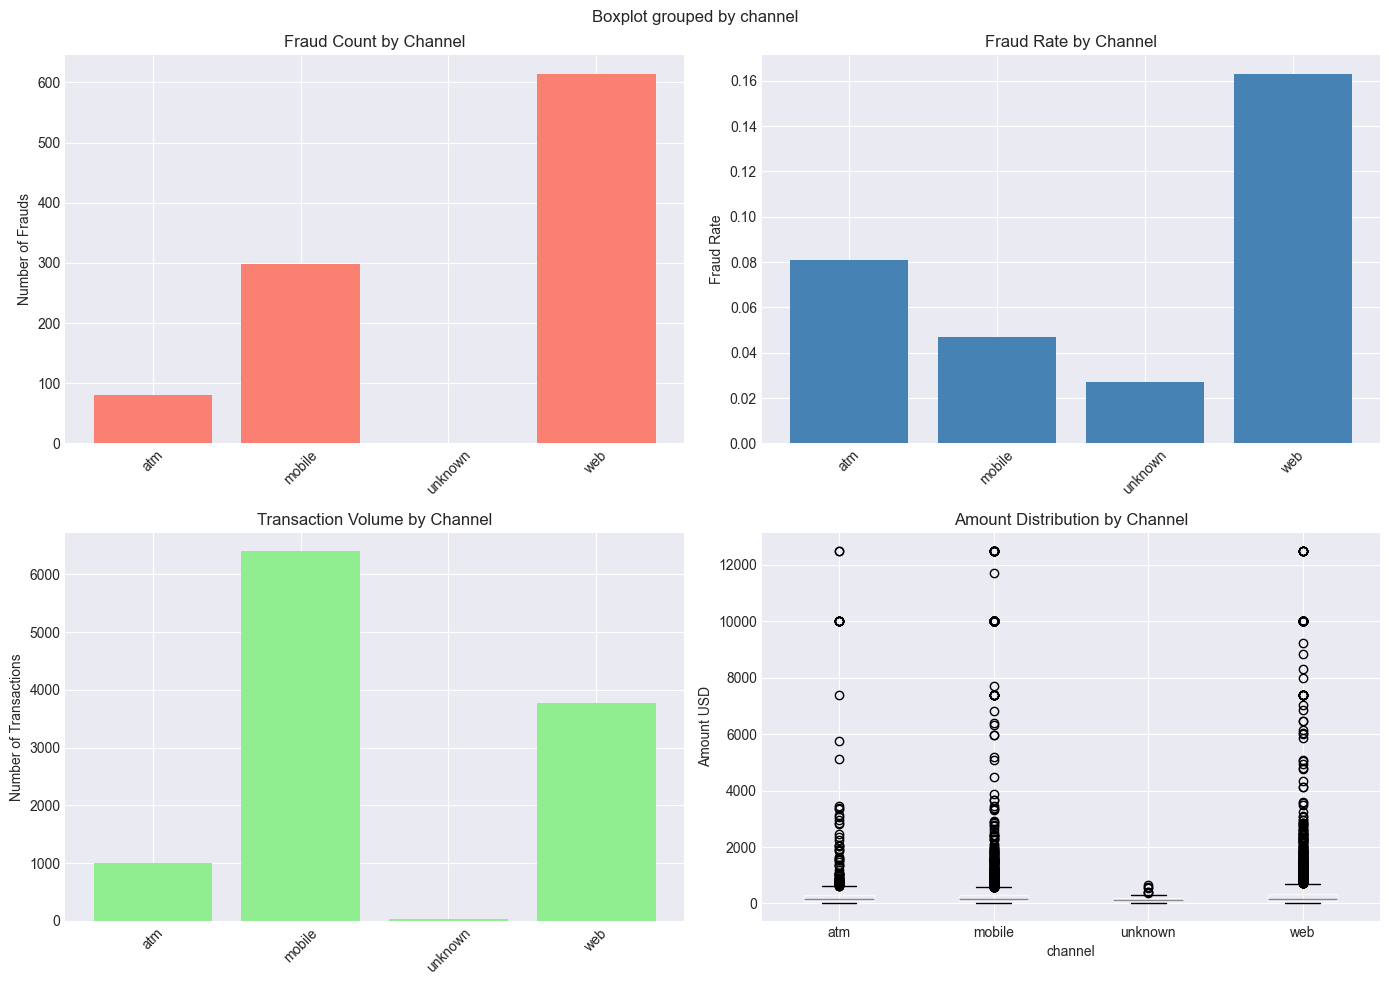

✓ Channel analysis complete


In [50]:
# Channel analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fraud Analysis by Payment Channel', fontsize=16, fontweight='bold')

# 1. Fraud count by channel
if 'channel' in df_eda.columns:
    channel_fraud = df_eda.groupby('channel')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
    channel_fraud.columns = ['channel', 'fraud_count', 'total', 'fraud_rate']
    
    axes[0, 0].bar(channel_fraud['channel'], channel_fraud['fraud_count'], color='salmon')
    axes[0, 0].set_title('Fraud Count by Channel')
    axes[0, 0].set_ylabel('Number of Frauds')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Fraud rate by channel
    axes[0, 1].bar(channel_fraud['channel'], channel_fraud['fraud_rate'], color='steelblue')
    axes[0, 1].set_title('Fraud Rate by Channel')
    axes[0, 1].set_ylabel('Fraud Rate')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Transaction volume by channel
    axes[1, 0].bar(channel_fraud['channel'], channel_fraud['total'], color='lightgreen')
    axes[1, 0].set_title('Transaction Volume by Channel')
    axes[1, 0].set_ylabel('Number of Transactions')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. Amount distribution by channel and fraud
    if 'amount_usd' in df_eda.columns:
        df_eda.boxplot(column='amount_usd', by='channel', ax=axes[1, 1])
        axes[1, 1].set_title('Amount Distribution by Channel')
        axes[1, 1].set_ylabel('Amount USD')
        
    print('Channel Analysis:')
    print(channel_fraud)
    print(f'\nHighest fraud rate channel: {channel_fraud.loc[channel_fraud["fraud_rate"].idxmax()]}')
else:
    print('Channel column not found')

plt.tight_layout()
plt.savefig('../visualizations/04_fraud_by_channel.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Channel analysis complete')

### 4.3: Geographic Analysis

Location Mismatch Impact:
   country_location_mismatch    sum  count      mean
0                          0  330.0   9014  0.036610
1                          1  665.0   2186  0.304209


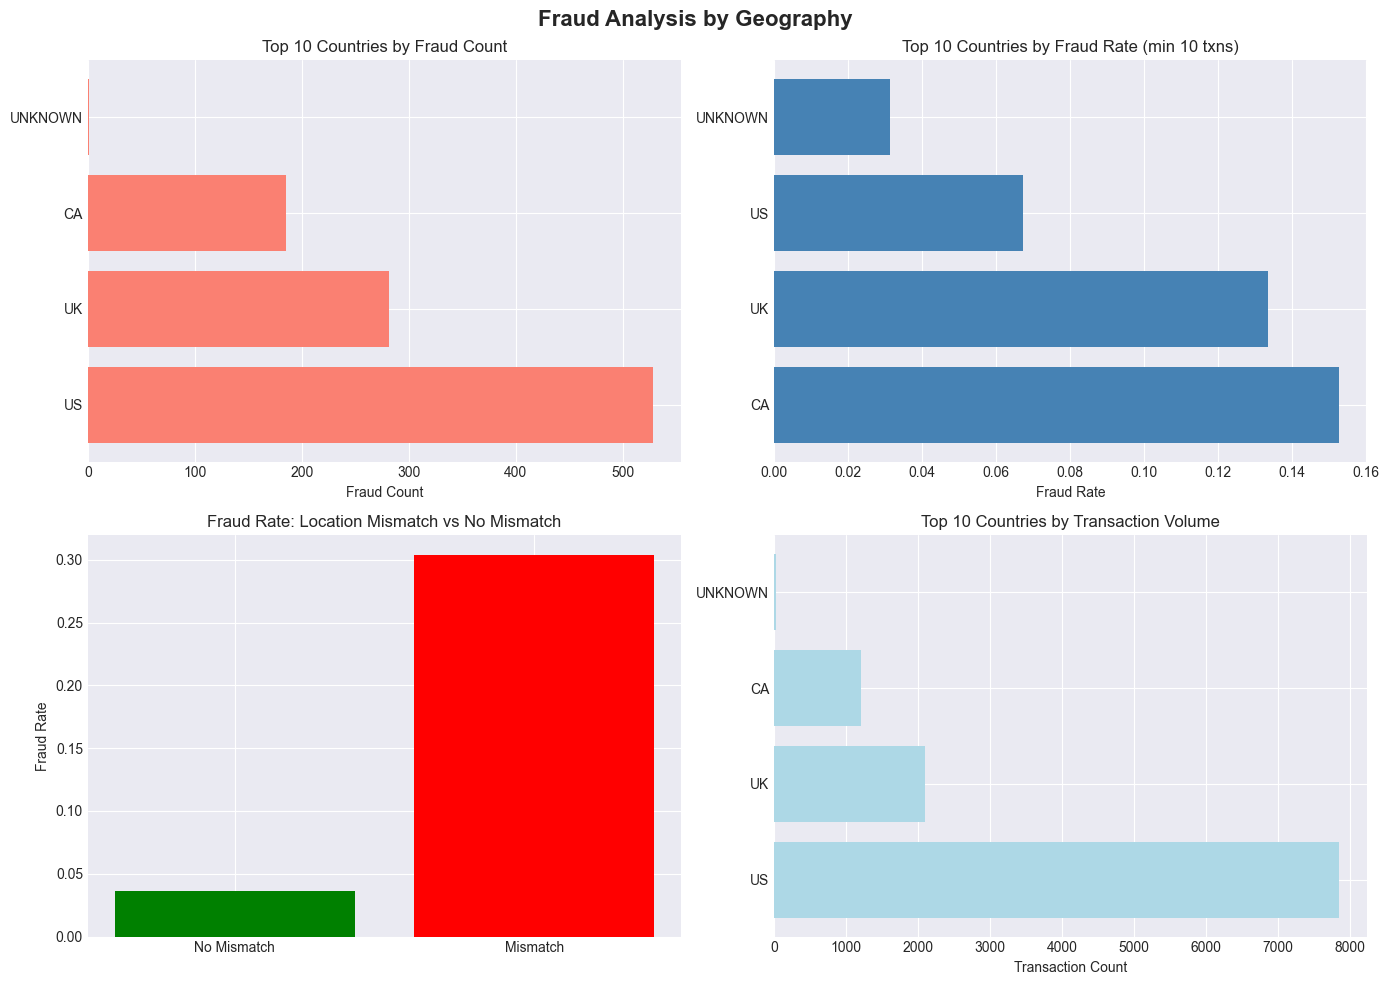

✓ Geographic analysis complete


In [51]:
# Geographic analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fraud Analysis by Geography', fontsize=16, fontweight='bold')

if 'home_country' in df_eda.columns:
    # 1. Fraud by country (top 10)
    country_fraud = df_eda.groupby('home_country')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
    country_fraud.columns = ['country', 'fraud_count', 'total', 'fraud_rate']
    country_fraud = country_fraud.sort_values('fraud_count', ascending=False).head(10)
    
    axes[0, 0].barh(country_fraud['country'], country_fraud['fraud_count'], color='salmon')
    axes[0, 0].set_title('Top 10 Countries by Fraud Count')
    axes[0, 0].set_xlabel('Fraud Count')
    
    # 2. Fraud rate by country (top 10 by rate)
    country_fraud_rate = df_eda.groupby('home_country')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
    country_fraud_rate.columns = ['country', 'fraud_count', 'total', 'fraud_rate']
    country_fraud_rate = country_fraud_rate[country_fraud_rate['total'] >= 10].sort_values('fraud_rate', ascending=False).head(10)
    
    axes[0, 1].barh(country_fraud_rate['country'], country_fraud_rate['fraud_rate'], color='steelblue')
    axes[0, 1].set_title('Top 10 Countries by Fraud Rate (min 10 txns)')
    axes[0, 1].set_xlabel('Fraud Rate')

if 'country_location_mismatch' in df_eda.columns or ('home_country' in df_eda.columns and 'ip_country' in df_eda.columns):
    # Create country mismatch feature if needed
    if 'country_location_mismatch' not in df_eda.columns:
        df_eda['country_location_mismatch'] = (df_eda['home_country'] != df_eda['ip_country']).astype(int)
    
    mismatch_fraud = df_eda.groupby('country_location_mismatch')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
    mismatch_labels = ['No Mismatch', 'Mismatch']
    
    axes[1, 0].bar(mismatch_labels, mismatch_fraud['mean'], color=['green', 'red'])
    axes[1, 0].set_title('Fraud Rate: Location Mismatch vs No Mismatch')
    axes[1, 0].set_ylabel('Fraud Rate')
    
    print('Location Mismatch Impact:')
    print(mismatch_fraud)

# 4. Transaction volume by country (top 10)
if 'home_country' in df_eda.columns:
    country_volume = df_eda['home_country'].value_counts().head(10)
    axes[1, 1].barh(country_volume.index, country_volume.values, color='lightblue')
    axes[1, 1].set_title('Top 10 Countries by Transaction Volume')
    axes[1, 1].set_xlabel('Transaction Count')

plt.tight_layout()
plt.savefig('../visualizations/04_fraud_by_geography.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Geographic analysis complete')

### 4.4: Temporal Analysis

Weekday vs Weekend Fraud Comparison:
   is_weekday    sum  count      mean
0       False  276.0   3126  0.088292
1        True  719.0   8074  0.089051


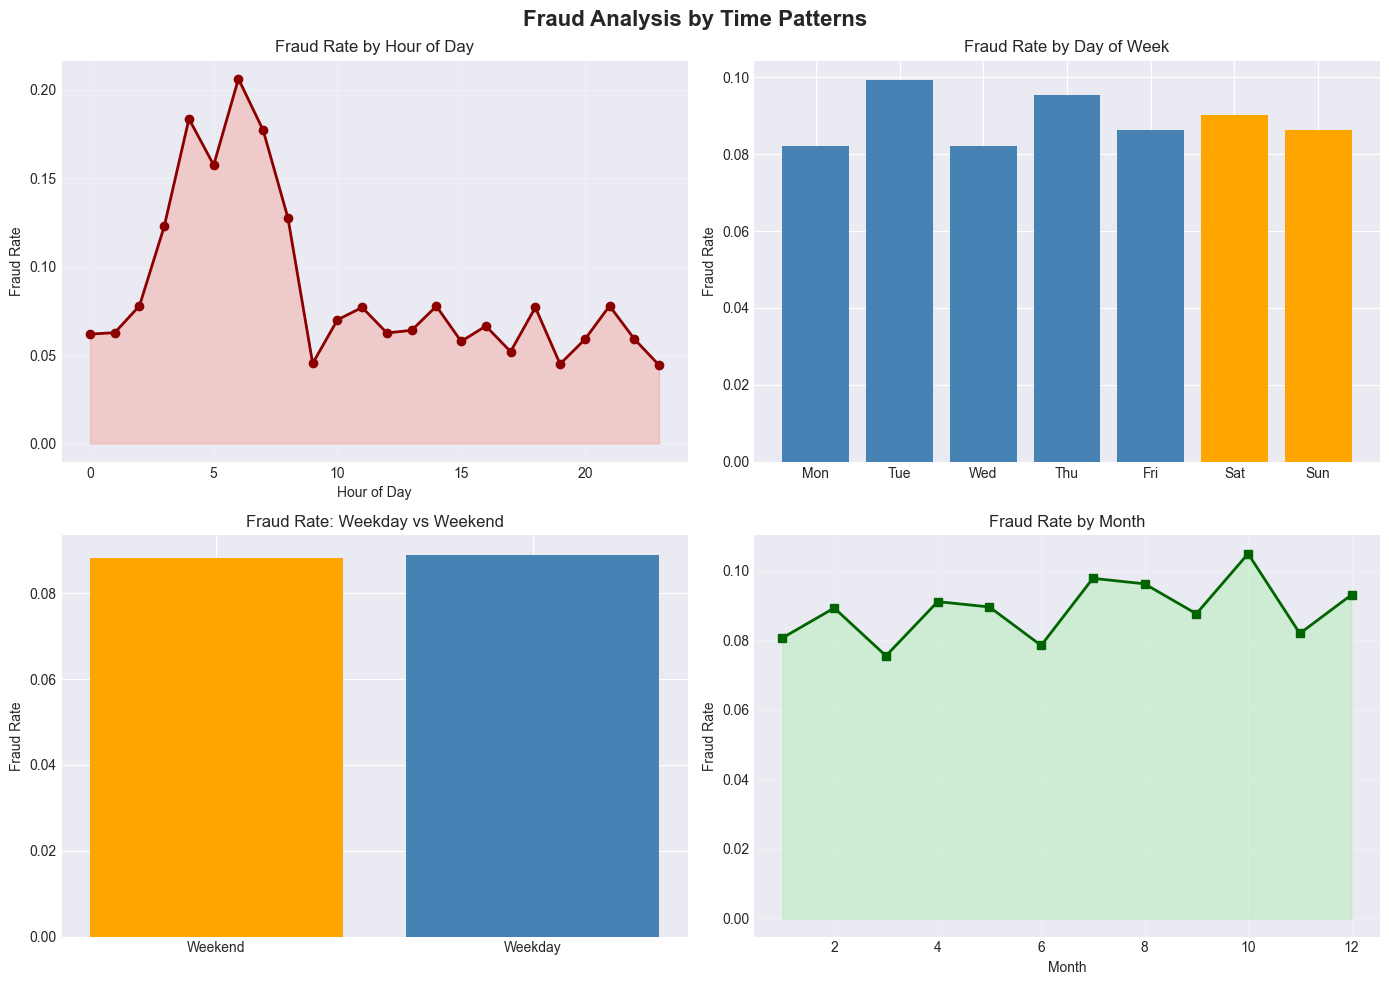

✓ Temporal analysis complete


In [52]:
# Temporal analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fraud Analysis by Time Patterns', fontsize=16, fontweight='bold')

# 1. Hourly fraud pattern
hourly_fraud = df_eda.groupby('hour')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
axes[0, 0].plot(hourly_fraud['hour'], hourly_fraud['mean'], marker='o', linewidth=2, color='darkred')
axes[0, 0].fill_between(hourly_fraud['hour'], hourly_fraud['mean'], alpha=0.3, color='salmon')
axes[0, 0].set_title('Fraud Rate by Hour of Day')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Fraud Rate')
axes[0, 0].grid(True, alpha=0.3)

# 2. Daily fraud pattern
daily_fraud = df_eda.groupby('day_of_week')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(day_names, daily_fraud['mean'], color=['steelblue']*5 + ['orange']*2)
axes[0, 1].set_title('Fraud Rate by Day of Week')
axes[0, 1].set_ylabel('Fraud Rate')

# 3. Weekday vs weekend
if 'is_weekday' in df_eda.columns:
    weekday_fraud = df_eda.groupby('is_weekday')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
    axes[1, 0].bar(['Weekend', 'Weekday'], weekday_fraud['mean'], color=['orange', 'steelblue'])
    axes[1, 0].set_title('Fraud Rate: Weekday vs Weekend')
    axes[1, 0].set_ylabel('Fraud Rate')
    
    print('Weekday vs Weekend Fraud Comparison:')
    print(weekday_fraud)

# 4. Monthly trend
if 'month' in df_eda.columns:
    monthly_fraud = df_eda.groupby('month')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
    axes[1, 1].plot(monthly_fraud['month'], monthly_fraud['mean'], marker='s', linewidth=2, color='darkgreen')
    axes[1, 1].fill_between(monthly_fraud['month'], monthly_fraud['mean'], alpha=0.3, color='lightgreen')
    axes[1, 1].set_title('Fraud Rate by Month')
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('Fraud Rate')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/04_fraud_by_time.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Temporal analysis complete')

### 4.5: Heatmap - Hour × Day of Week

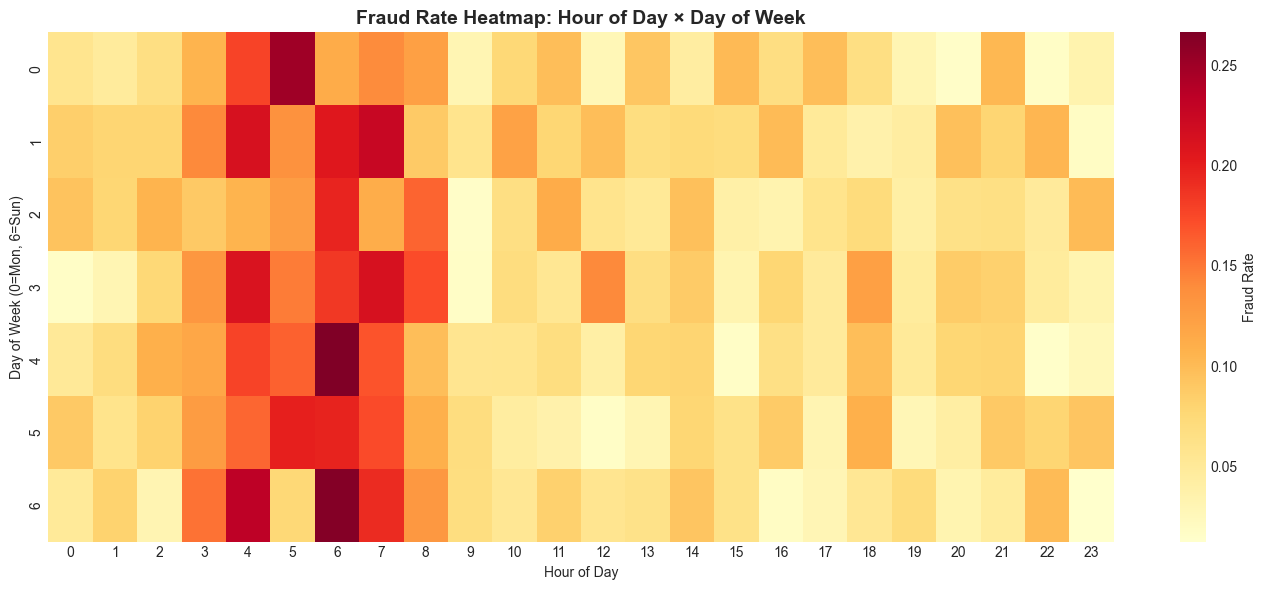

✓ Heatmap analysis complete


In [53]:
# Create hour × day-of-week heatmap
heatmap_data = df_eda.groupby(['day_of_week', 'hour'])['is_fraud'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Fraud Rate'}, ax=ax)
ax.set_title('Fraud Rate Heatmap: Hour of Day × Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Day of Week (0=Mon, 6=Sun)')
ax.set_xlabel('Hour of Day')

plt.tight_layout()
plt.savefig('../visualizations/04_fraud_heatmap_hour_day.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Heatmap analysis complete')

### 4.6: Anomaly Detection - Behavioral Differences

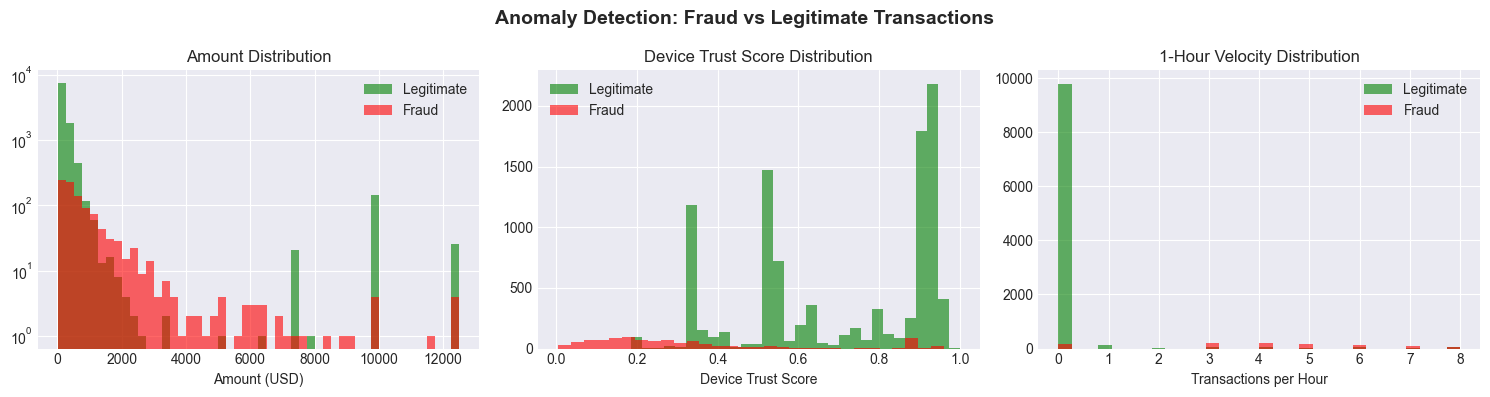

✓ Anomaly detection analysis complete


In [54]:
# Compare behavior of fraudulent vs legitimate transactions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Anomaly Detection: Fraud vs Legitimate Transactions', fontsize=14, fontweight='bold')

# 1. Amount distribution
if 'amount_usd' in df_eda.columns:
    df_eda[df_eda['is_fraud'] == 0]['amount_usd'].hist(bins=50, alpha=0.6, label='Legitimate', ax=axes[0], color='green')
    df_eda[df_eda['is_fraud'] == 1]['amount_usd'].hist(bins=50, alpha=0.6, label='Fraud', ax=axes[0], color='red')
    axes[0].set_title('Amount Distribution')
    axes[0].set_xlabel('Amount (USD)')
    axes[0].legend()
    axes[0].set_yscale('log')

# 2. Device trust score
if 'device_trust_score' in df_eda.columns:
    df_eda[df_eda['is_fraud'] == 0]['device_trust_score'].hist(bins=30, alpha=0.6, label='Legitimate', ax=axes[1], color='green')
    df_eda[df_eda['is_fraud'] == 1]['device_trust_score'].hist(bins=30, alpha=0.6, label='Fraud', ax=axes[1], color='red')
    axes[1].set_title('Device Trust Score Distribution')
    axes[1].set_xlabel('Device Trust Score')
    axes[1].legend()

# 3. Transaction velocity
if 'txn_velocity_1h' in df_eda.columns:
    df_eda[df_eda['is_fraud'] == 0]['txn_velocity_1h'].hist(bins=30, alpha=0.6, label='Legitimate', ax=axes[2], color='green')
    df_eda[df_eda['is_fraud'] == 1]['txn_velocity_1h'].hist(bins=30, alpha=0.6, label='Fraud', ax=axes[2], color='red')
    axes[2].set_title('1-Hour Velocity Distribution')
    axes[2].set_xlabel('Transactions per Hour')
    axes[2].legend()

plt.tight_layout()
plt.savefig('../visualizations/04_anomaly_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Anomaly detection analysis complete')

### 4.7: Feature Correlation with Fraud

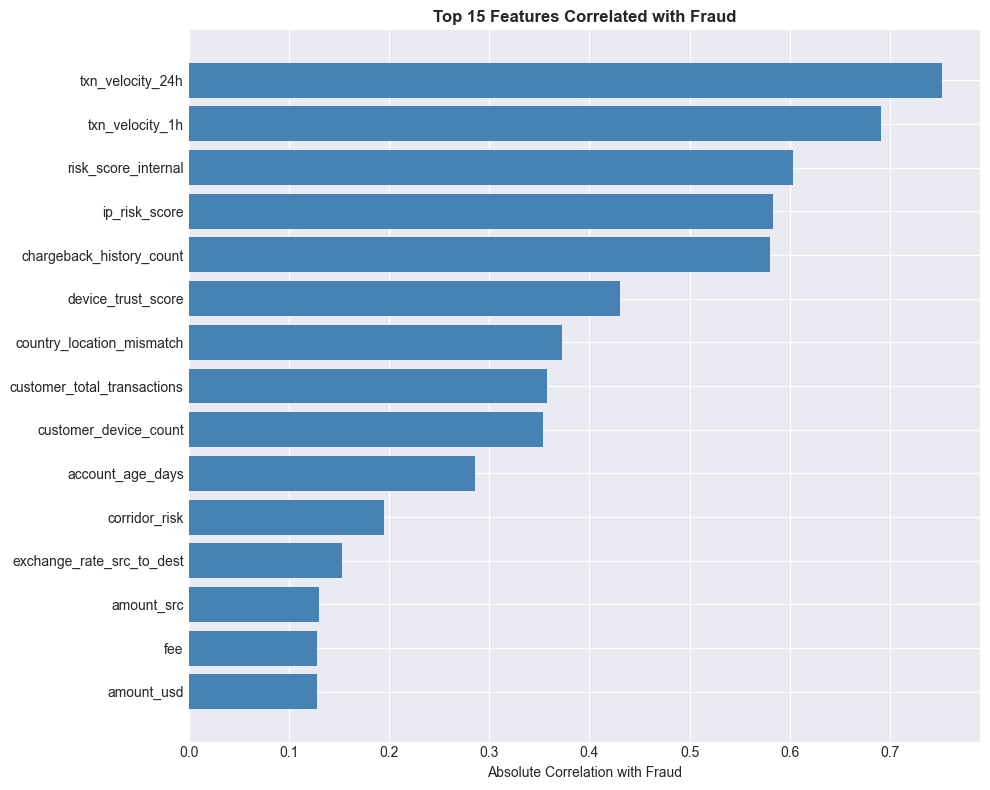

Feature Correlation with Fraud (Top 15):
                             correlation        p_value
txn_velocity_24h                0.752129   0.000000e+00
txn_velocity_1h                 0.690714   0.000000e+00
risk_score_internal             0.603606   0.000000e+00
ip_risk_score                   0.582857   0.000000e+00
chargeback_history_count        0.580417   0.000000e+00
device_trust_score              0.430984   0.000000e+00
country_location_mismatch       0.372778   0.000000e+00
customer_total_transactions     0.357864   0.000000e+00
customer_device_count           0.353752   0.000000e+00
account_age_days                0.285965  9.319665e-210
corridor_risk                   0.194903   2.609189e-96
exchange_rate_src_to_dest       0.152899   1.478157e-59
amount_src                      0.130350   1.228565e-43
fee                             0.128614   1.608532e-42
amount_usd                      0.128570   1.717614e-42
✓ Correlation analysis complete


In [55]:
# Calculate point-biserial correlation with fraud
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
correlations = {}

for col in numeric_cols:
    if col != 'is_fraud':
        try:
            corr, p_value = pointbiserialr(df_eda['is_fraud'], df_eda[col].fillna(df_eda[col].mean()))
            correlations[col] = {'correlation': abs(corr), 'p_value': p_value}
        except:
            pass

# Sort by absolute correlation
corr_df = pd.DataFrame(correlations).T.sort_values('correlation', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(corr_df)), corr_df['correlation'], color='steelblue')
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df.index)
ax.set_xlabel('Absolute Correlation with Fraud')
ax.set_title('Top 15 Features Correlated with Fraud', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../visualizations/04_fraud_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print('Feature Correlation with Fraud (Top 15):')
print(corr_df)
print('✓ Correlation analysis complete')

In [56]:
# Generate EDA summary report
print('\n' + '='*80)
print('STEP 4 COMPLETE: EXPLORATORY DATA ANALYSIS SUMMARY')
print('='*80)

print(f'\n1. CLASS DISTRIBUTION:')
print(f'   Total Transactions: {len(df_eda):,}')
print(f'   Fraud Cases: {df_eda["is_fraud"].sum():,}')
print(f'   Legitimate Cases: {(df_eda["is_fraud"] == 0).sum():,}')
print(f'   Fraud Rate: {df_eda["is_fraud"].mean():.2%}')
print(f'   Class Imbalance Ratio: 1:{(df_eda["is_fraud"] == 0).sum() / df_eda["is_fraud"].sum():.1f}')

if 'channel' in df_eda.columns:
    print(f'\n2. CHANNEL INSIGHTS:')
    for idx, row in channel_fraud.iterrows():
        print(f'   {row["channel"]}: {row["fraud_rate"]:.2%} fraud rate ({row["fraud_count"]} cases)')

if 'country_location_mismatch' in df_eda.columns:
    print(f'\n3. GEOGRAPHIC INSIGHTS:')
    mismatch_stats = df_eda.groupby('country_location_mismatch')['is_fraud'].agg(['sum', 'count', 'mean'])
    print(f'   With Location Mismatch: {mismatch_stats.loc[1, "mean"]:.2%} fraud rate')
    print(f'   No Location Mismatch: {mismatch_stats.loc[0, "mean"]:.2%} fraud rate')
    print(f'   Risk Multiplier: {mismatch_stats.loc[1, "mean"] / mismatch_stats.loc[0, "mean"]:.2f}x')

print(f'\n4. TEMPORAL INSIGHTS:')
print(f'   Highest Risk Hour: {hourly_fraud.loc[hourly_fraud["mean"].idxmax(), "hour"]:.0f}:00 ({hourly_fraud["mean"].max():.2%})')
print(f'   Lowest Risk Hour: {hourly_fraud.loc[hourly_fraud["mean"].idxmin(), "hour"]:.0f}:00 ({hourly_fraud["mean"].min():.2%})')

if 'is_weekday' in df_eda.columns:
    weekday_rate = df_eda[df_eda['is_weekday'] == True]['is_fraud'].mean()
    weekend_rate = df_eda[df_eda['is_weekday'] == False]['is_fraud'].mean()
    print(f'   Weekday Fraud Rate: {weekday_rate:.2%}')
    print(f'   Weekend Fraud Rate: {weekend_rate:.2%}')

print(f'\n5. TOP FRAUD INDICATORS (correlation):')
for idx, (feature, row) in enumerate(corr_df.iterrows(), 1):
    print(f'   {idx}. {feature}: {row["correlation"]:.3f}')

print('\n' + '='*80)
print('Analysis complete. Visualizations saved to ../visualizations/')
print('='*80)


STEP 4 COMPLETE: EXPLORATORY DATA ANALYSIS SUMMARY

1. CLASS DISTRIBUTION:
   Total Transactions: 11,200
   Fraud Cases: 995.0
   Legitimate Cases: 10,205
   Fraud Rate: 8.88%
   Class Imbalance Ratio: 1:10.3

2. CHANNEL INSIGHTS:
   atm: 8.08% fraud rate (81.0 cases)
   mobile: 4.68% fraud rate (299.0 cases)
   unknown: 2.70% fraud rate (1.0 cases)
   web: 16.30% fraud rate (614.0 cases)

3. GEOGRAPHIC INSIGHTS:
   With Location Mismatch: 30.42% fraud rate
   No Location Mismatch: 3.66% fraud rate
   Risk Multiplier: 8.31x

4. TEMPORAL INSIGHTS:
   Highest Risk Hour: 6:00 (20.62%)
   Lowest Risk Hour: 23:00 (4.43%)
   Weekday Fraud Rate: 8.91%
   Weekend Fraud Rate: 8.83%

5. TOP FRAUD INDICATORS (correlation):
   1. txn_velocity_24h: 0.752
   2. txn_velocity_1h: 0.691
   3. risk_score_internal: 0.604
   4. ip_risk_score: 0.583
   5. chargeback_history_count: 0.580
   6. device_trust_score: 0.431
   7. country_location_mismatch: 0.373
   8. customer_total_transactions: 0.358
   9. cu

---
## 📚 TEACHING NOTE — Looking ahead: what is hyperparameter tuning, and why?

Your cleaned, encoded dataset now feeds the modelling notebook (Steps 5 & 6). Two concepts there are worth understanding *now*, because they motivate why we prepared the data this way.

### Parameters vs hyperparameters
- **Parameters** are what the model *learns by itself* from the data during training (e.g. the weights in logistic regression, the split points inside a tree). You never set these by hand.
- **Hyperparameters** are the *settings you choose before training* that control *how* the model learns — for example, how many trees a Random Forest builds (`n_estimators`), how deep each tree may grow (`max_depth`), or how big each learning step is in XGBoost (`learning_rate`).

A useful analogy: if training is baking, the **parameters** are the final taste the batter settles into, while the **hyperparameters** are the oven temperature and baking time *you* dial in beforehand. Wrong settings → undercooked (underfitting) or burnt (overfitting).

### Why tune them?
The default settings are rarely best for *your* data. Tuning searches different combinations to find the ones that perform best — measured by cross-validation, not on the holdout test set (which stays untouched until the very end).

- **Too simple** (e.g. very shallow trees) → **underfitting**: the model misses real fraud patterns.
- **Too complex** (e.g. very deep trees, too many) → **overfitting**: the model memorises the training data, including noise, and fails on new transactions.

Tuning finds the sweet spot in between.

### How we tune (preview of Step 5)
- **Grid search** tries every combination in a list you specify — thorough but slow.
- **Randomized search** samples a fixed number of random combinations — far faster and usually nearly as good. This is what the modelling notebook uses.
- Each candidate is scored with **k-fold cross-validation**: the training data is split into k parts, the model trains on k−1 and validates on the held-out part, rotating through all parts and averaging. This gives a stable estimate without ever touching the final test set.
- For imbalanced fraud data we tune toward **PR-AUC / F1 / recall**, never plain accuracy — a model that predicts "never fraud" scores 99% accuracy while catching zero fraud.

### Why the data prep you just did matters for tuning
Tuning only helps if the inputs are sound. Because we separated identifiers, the model tunes over *meaningful behaviour features* (counts, risk scores, velocities) instead of thousands of useless ID dummy-columns. Clean inputs → tuning that actually improves fraud detection rather than chasing noise.

➡  **Next:** open the modelling notebook (Steps 5 & 6) to build, tune, validate, and explain the models.